# Clase 12 — Pandas y tu primer clasificador 

En la Clase 11 dejamos un dataset de frutas limpio, ordenado y guardado en un CSV. Los datos para un modelo de IA pueden venir de un archivo, de una consulta SQL o de una API: lo importante es que terminen en un `DataFrame` de pandas, como venimos haciendo.

Hoy damos el salto que estábamos preparando: usar esos datos para entrenar un modelo que **clasifique**. Nada nuevo en teoría (eso ya lo vimos en el Módulo 2) — hoy el objetivo es divertirnos armando nuestro propio ejemplo, de punta a punta, con gráficos.

**Objetivos de la clase:**
- Armar un dataset de juguete con pandas: frutas dulces vs. cítricas.
- Visualizar los datos con un scatter plot antes de entrenar nada.
- Separar en train/test y entrenar un modelo KNN.
- Leer una matriz de confusión como un gráfico (heatmap), no solo como números.
- Divertirnos prediciendo frutas inventadas por nosotros.


---
## 1. Armar el dataset con pandas

Vamos a inventar un dataset pequeño y divertido: frutas descritas por dos números, `dulzura` y `acidez` (ambas de 0 a 10), etiquetadas como `dulce` o `citrico`. Usamos `np.random.seed(42)` para que a todos nos salgan los mismos datos.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_por_clase = 25

dulces = pd.DataFrame({
    "dulzura": np.random.normal(loc=6.5, scale=1.3, size=n_por_clase),
    "acidez": np.random.normal(loc=4.0, scale=1.3, size=n_por_clase),
    "clase": "dulce",
})

citricas = pd.DataFrame({
    "dulzura": np.random.normal(loc=4.5, scale=1.3, size=n_por_clase),
    "acidez": np.random.normal(loc=6.0, scale=1.3, size=n_por_clase),
    "clase": "citrico",
})

frutas = pd.concat([dulces, citricas], ignore_index=True)

print("Forma del dataset:", frutas.shape)
frutas.sample(5, random_state=1)


Forma del dataset: (50, 3)


,dulzura,acidez,clase
27,3.620001,5.611290,citrico
35,3.877073,5.347716,citrico
40,6.263112,6.126201,citrico
38,2.944931,5.311312,citrico
2,7.341995,4.488407,dulce


---
## 2. Visualizar antes de entrenar

Un buen hábito: **mirar los datos antes de entrenar cualquier modelo**. Un scatter plot con color por clase nos muestra si el problema es "fácil" (grupos separados) o "difícil" (grupos mezclados).


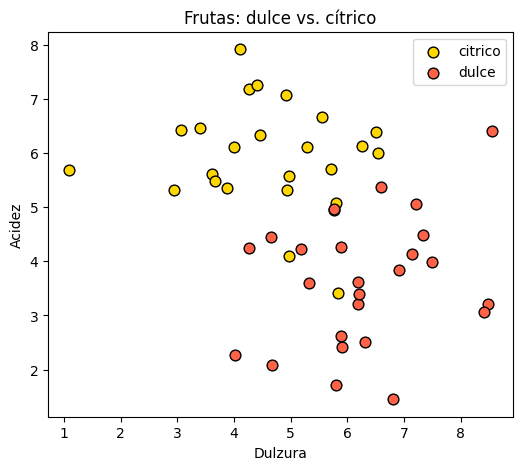

In [6]:
import matplotlib.pyplot as plt

colores = {"dulce": "tomato", "citrico": "gold"}

fig, ax = plt.subplots(figsize=(6, 5))
for clase, grupo in frutas.groupby("clase"):
    ax.scatter(grupo["dulzura"], grupo["acidez"], label=clase, color=colores[clase], edgecolor="black", s=60)

ax.set_xlabel("Dulzura")
ax.set_ylabel("Acidez")
ax.set_title("Frutas: dulce vs. cítrico")
ax.legend()
plt.show()


---
## 3. Entrenar un modelo KNN

Repasamos el flujo que ya conocemos de Módulo 2: separar en train/test y entrenar. Usamos `KNeighborsClassifier`, el más intuitivo: clasifica cada punto según sus vecinos más cercanos en el gráfico de arriba.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = frutas[["dulzura", "acidez"]]
y = frutas["clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print("Train:", X_train.shape[0], "frutas — Test:", X_test.shape[0], "frutas")
print("Primeras predicciones:", list(y_pred[:5]))


Train: 37 frutas — Test: 13 frutas
Primeras predicciones: ['dulce', 'dulce', 'citrico', 'citrico', 'dulce']


---
## 4. La matriz de confusión, como gráfico

En Módulo 2 vimos la matriz de confusión como tabla de números. Con `seaborn.heatmap` se lee mucho más rápido: los colores fuertes en la diagonal significan aciertos.


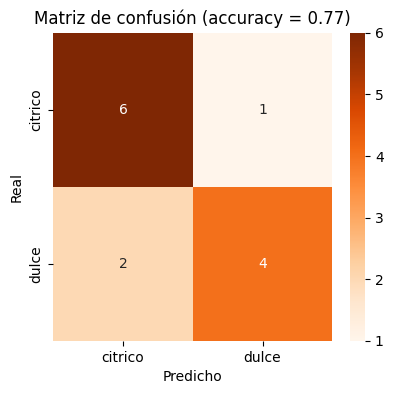

In [4]:
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

exactitud = accuracy_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Oranges",
    xticklabels=modelo.classes_, yticklabels=modelo.classes_, ax=ax,
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión (accuracy = {exactitud:.2f})")
plt.show()


---
## 📝 Actividad — Inventá tu propia fruta

**Consigna:**
- Elegí valores de `dulzura` y `acidez` para una fruta inventada por vos (por ejemplo, un "limón dulce").
- Pedile al modelo que la clasifique con `.predict(...)`.
- Volvé a dibujar el scatter plot de la sección 2, agregando tu fruta como una estrella para ver visualmente dónde cae.


Tu fruta fue clasificada como: citrico


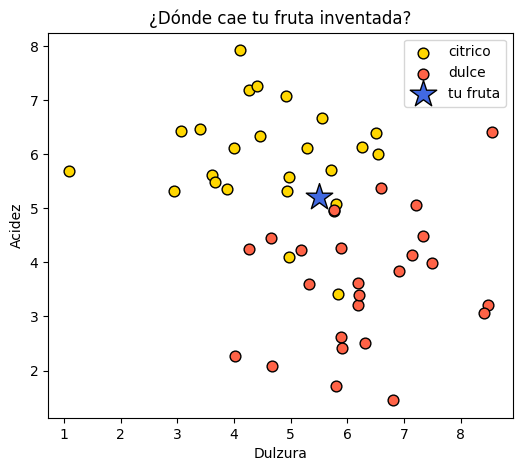

In [5]:
# ACTIVIDAD: inventar una fruta y clasificarla
# TODO: elegir dulzura y acidez para tu fruta inventada
mi_fruta = pd.DataFrame({"dulzura": [5.5], "acidez": [5.2]})

# TODO: predecir su clase
prediccion = modelo.predict(mi_fruta)[0]
print("Tu fruta fue clasificada como:", prediccion)

# Graficar el dataset + tu fruta inventada
fig, ax = plt.subplots(figsize=(6, 5))
for clase, grupo in frutas.groupby("clase"):
    ax.scatter(grupo["dulzura"], grupo["acidez"], label=clase, color=colores[clase], edgecolor="black", s=60)

ax.scatter(
    mi_fruta["dulzura"], mi_fruta["acidez"],
    marker="*", s=400, color="royalblue", edgecolor="black", label="tu fruta",
)
ax.set_xlabel("Dulzura")
ax.set_ylabel("Acidez")
ax.set_title("¿Dónde cae tu fruta inventada?")
ax.legend()
plt.show()


---
## ✅ Resumen

| Herramienta | Qué resuelve |
|---|---|
| `pd.concat([...])` | Armar un dataset combinando grupos |
| `ax.scatter(..., color=...)` | Visualizar los datos antes de entrenar |
| `train_test_split`, `KNeighborsClassifier` | Repaso del flujo de Módulo 2 |
| `sns.heatmap(confusion_matrix(...))` | Leer la matriz de confusión como gráfico |
| `modelo.predict(...)` | Clasificar un dato nuevo, inventado por vos |

**Lo que construiste hoy:**
- un dataset de juguete armado con pandas,
- un modelo KNN entrenado y evaluado con un gráfico en vez de solo números,
- la clasificación de una fruta inventada por vos mismo.

**Lo que viene:**
- **Clase 13**: vamos a entrenar más de un modelo sobre el mismo dataset y comparar sus resultados con gráficas, como en Módulo 2 pero con nuestros propios datos.
